# NYC TLC 2024-01 운행 데이터 분석

`jobs/` 아래 Spark 잡들이 `/opt/output`에 저장한 결과를 읽어와 시각화한다.

- `trip_metrics`: 평균 이동시간/거리
- `peak_hours`: 시간대별 운행 분포 및 피크 시간대
- `weather_correlation`: 기상 조건과 운행 수요의 상관관계

In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "/opt/output"


def load_csv(subpath):
    # Spark가 여러 part-*.csv로 나눠 쓴 결과를 하나의 DataFrame으로 합쳐서 읽음
    files = sorted(glob.glob(f"{OUTPUT_DIR}/{subpath}/part-*.csv"))
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

## 1. 핵심 지표: 평균 이동시간 / 이동거리

In [2]:
metrics_df = load_csv("trip_metrics")
metrics_df

,avg_trip_duration_minutes,avg_trip_distance_miles,trip_count
0,17.18,3.36,23269365


In [3]:
row = metrics_df.iloc[0]
print(f"전체 {row['trip_count']:,}건 기준")
print(f"평균 이동시간: {row['avg_trip_duration_minutes']}분")
print(f"평균 이동거리: {row['avg_trip_distance_miles']}마일")

전체 23,269,365.0건 기준
평균 이동시간: 17.18분
평균 이동거리: 3.36마일


## 2. 피크 시간대 분석

시간당 출발 건수를 기준으로 24시간 분포를 그리고, 이용 횟수가 가장 많은 시간대를 강조한다.

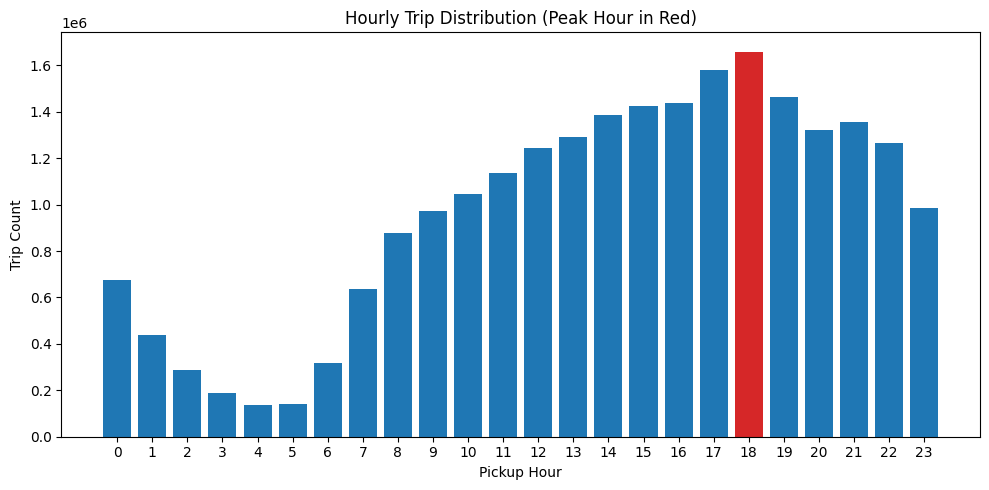

피크 시간대: 18:00, 1,659,438건


In [4]:
peak_df = load_csv("peak_hours").sort_values("pickup_hour")
colors = ["#d62728" if is_peak else "#1f77b4" for is_peak in peak_df["is_peak"]]

plt.figure(figsize=(10, 5))
plt.bar(peak_df["pickup_hour"], peak_df["trip_count"], color=colors)
plt.xlabel("Pickup Hour")
plt.ylabel("Trip Count")
plt.title("Hourly Trip Distribution (Peak Hour in Red)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

peak_row = peak_df.loc[peak_df["is_peak"]].iloc[0]
print(f"피크 시간대: {int(peak_row['pickup_hour']):02d}:00, {peak_row['trip_count']:,}건")

## 3. 기상 조건과 운행 수요의 상관관계

시간 단위로 결합한 운행건수-기온-강수량 데이터와, `scipy.stats`로 검증한 상관계수/유의확률(p-value)을 확인한다.

In [5]:
hourly_df = load_csv("weather_correlation/hourly_joined")
hourly_df["obs_hour"] = pd.to_datetime(hourly_df["obs_hour"])
hourly_df = hourly_df.sort_values("obs_hour")

stats_df = load_csv("weather_correlation/stats_summary")
stats_df

,temp_corr,temp_pvalue,precip_corr,precip_pvalue,rainy_hours_avg_trips,dry_hours_avg_trips,ttest_statistic,ttest_pvalue
0,0.2172,0.0,0.0205,0.1434,4533.3,4553.6,-0.1434,0.886


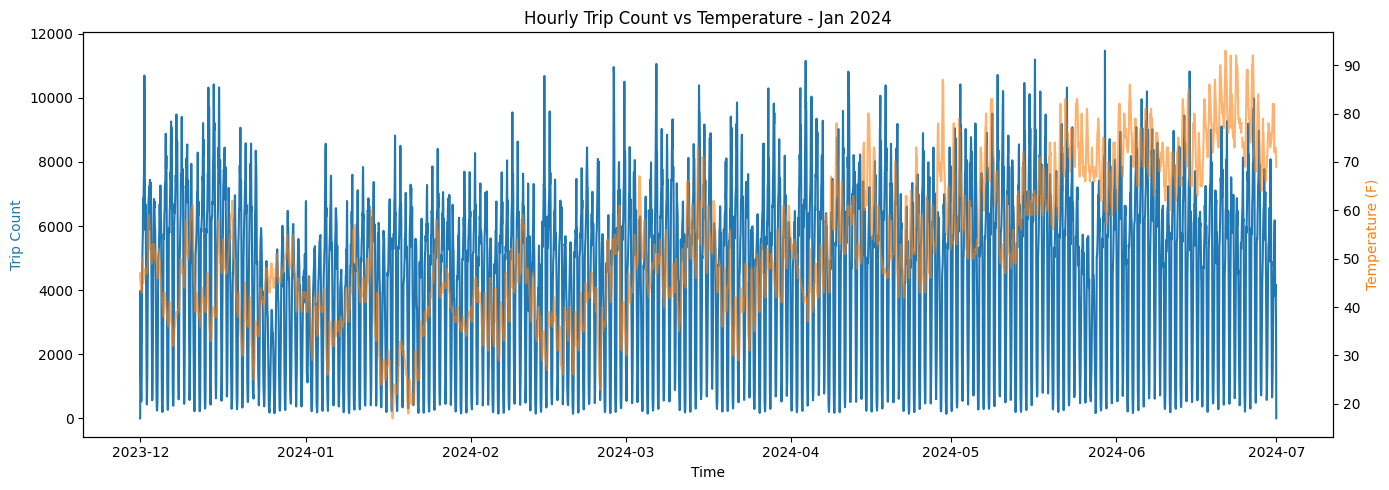

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(hourly_df["obs_hour"], hourly_df["trip_count"], color="#1f77b4", label="Trip Count")
ax1.set_xlabel("Time")
ax1.set_ylabel("Trip Count", color="#1f77b4")

ax2 = ax1.twinx()
ax2.plot(hourly_df["obs_hour"], hourly_df["temperature_f"], color="#ff7f0e", alpha=0.6, label="Temperature (F)")
ax2.set_ylabel("Temperature (F)", color="#ff7f0e")

plt.title("Hourly Trip Count vs Temperature - Jan 2024")
fig.tight_layout()
plt.show()

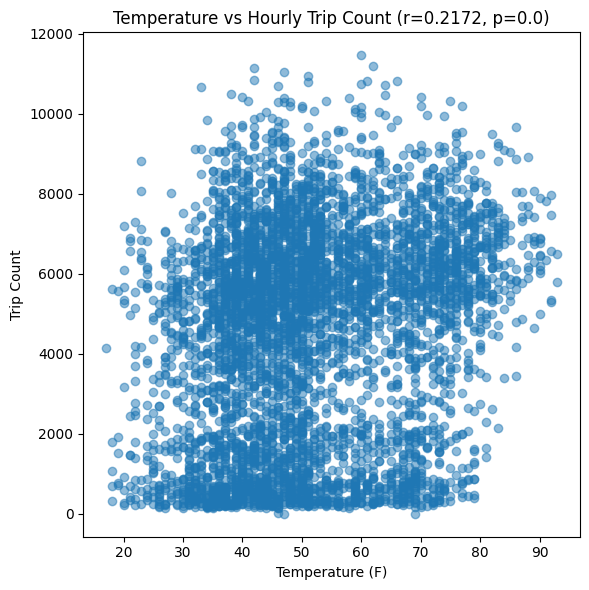

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(hourly_df["temperature_f"], hourly_df["trip_count"], alpha=0.5)
plt.xlabel("Temperature (F)")
plt.ylabel("Trip Count")
temp_corr = stats_df["temp_corr"].iloc[0]
temp_p = stats_df["temp_pvalue"].iloc[0]
plt.title(f"Temperature vs Hourly Trip Count (r={temp_corr}, p={temp_p})")
plt.tight_layout()
plt.show()

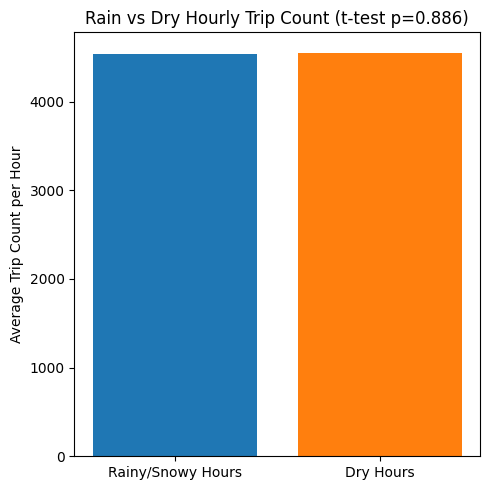

In [8]:
rainy_avg = stats_df["rainy_hours_avg_trips"].iloc[0]
dry_avg = stats_df["dry_hours_avg_trips"].iloc[0]
ttest_p = stats_df["ttest_pvalue"].iloc[0]

plt.figure(figsize=(5, 5))
plt.bar(["Rainy/Snowy Hours", "Dry Hours"], [rainy_avg, dry_avg], color=["#1f77b4", "#ff7f0e"])
plt.ylabel("Average Trip Count per Hour")
plt.title(f"Rain vs Dry Hourly Trip Count (t-test p={ttest_p})")
plt.tight_layout()
plt.show()

## 결론

- 평균 이동시간/거리는 2023년 12월~2024년 6월(7개월, 2개 연도), 클리닝된 약 2,327만 건 기준으로 계산됨
- 피크 시간대는 저녁 퇴근 시간대(18시)로, 데이터 기간을 늘려도 동일하게 유지됨
- 기온이 높을수록 운행건수가 늘어나는 상관관계가 계속 유의하게 나타남(r=0.217, p<0.0001) — 겨울(12월)부터 초여름까지 계절 변화가 반영된 결과로 보임
- 강수량 관련 결론은 데이터 기간에 따라 계속 달라짐: 1개월치(1월)만 봤을 때는 비/눈이 오는 시간에 운행건수가 유의하게 줄어드는 것처럼 보였지만(t-검정 p=0.0035), 6개월치(p=0.567)·7개월치(p=0.886)로 늘릴수록 그 차이가 통계적으로 유의하지 않다는 결론이 계속 재확인됨 — 표본 기간이 짧으면 우연한 패턴을 통계적으로 유의한 것처럼 착각할 수 있다는 걸 보여주는 사례
- TLC 데이터는 Parquet, 기상 데이터는 여러 연도(CSV, 연도별 파일)로 나뉘어 있어도 파이프라인이 자동으로 합쳐서 처리함 (`clean_trips.py`는 Parquet+CSV 혼합도 지원)